1. Setup — customer-level data ko Country ke saath merge karo (jaisa Day 46, 54-55 mein kiya tha):

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')

tx = pd.read_csv(
    '../data/processed/step4_datatypes_fixed.csv',
    dtype={'Invoice': str, 'StockCode': str},
    usecols=['Customer ID', 'Country']
)
cust_country = tx.groupby('Customer ID')['Country'].agg(lambda s: s.mode()[0]).reset_index()

df = df.merge(cust_country, on='Customer ID', how='left')
print(df['Country'].isnull().sum())
print(df.shape)

0
(5881, 8)


2. Country-wise customer count aur churn rate, ek table mein:

In [2]:
country_summary = df.groupby('Country').agg(
    total_customers=('Customer ID', 'nunique'),
    churned_customers=('Churned', 'sum'),
    churn_rate=('Churned', 'mean')
)
country_summary['churn_rate'] = (country_summary['churn_rate'] * 100).round(2)
country_summary = country_summary.sort_values('total_customers', ascending=False)
print(country_summary.head(15))

                 total_customers  churned_customers  churn_rate
Country                                                        
United Kingdom              5353               2735       51.09
Germany                      106                 37       34.91
France                        95                 34       35.79
Spain                         38                 18       47.37
Belgium                       28                 11       39.29
Portugal                      24                 12       50.00
Switzerland                   22                 10       45.45
Netherlands                   22                 16       72.73
Sweden                        19                 14       73.68
Italy                         17                  7       41.18
Finland                       14                  4       28.57
Australia                     14                  8       57.14
Norway                        13                  5       38.46
Channel Islands               13        

3. Sirf meaningful sample size wale countries filter karo (chhote countries mein 2-3 customers hone se churn rate 0% ya 100% misleading dikh sakta hai — yeh zaroori statistical caution hai):

In [3]:
MIN_CUSTOMERS = 20
reliable_countries = country_summary[country_summary['total_customers'] >= MIN_CUSTOMERS]
print(f"Countries with at least {MIN_CUSTOMERS} customers: {len(reliable_countries)}")
print(reliable_countries.sort_values('churn_rate', ascending=False))

Countries with at least 20 customers: 8
                total_customers  churned_customers  churn_rate
Country                                                       
Netherlands                  22                 16       72.73
United Kingdom             5353               2735       51.09
Portugal                     24                 12       50.00
Spain                        38                 18       47.37
Switzerland                  22                 10       45.45
Belgium                      28                 11       39.29
France                       95                 34       35.79
Germany                     106                 37       34.91


note: Agar kisi country mein sirf 3 customers hain aur sab churned hain, to uska "100% churn rate" statistically meaningless hai (bahut chhota sample) — yeh exactly wahi caution hai jo Day 46 mein chi-square ke expected counts check karte waqt dekha tha.

4. Bar chart — churn rate by country, sirf reliable countries ke saath, sorted:

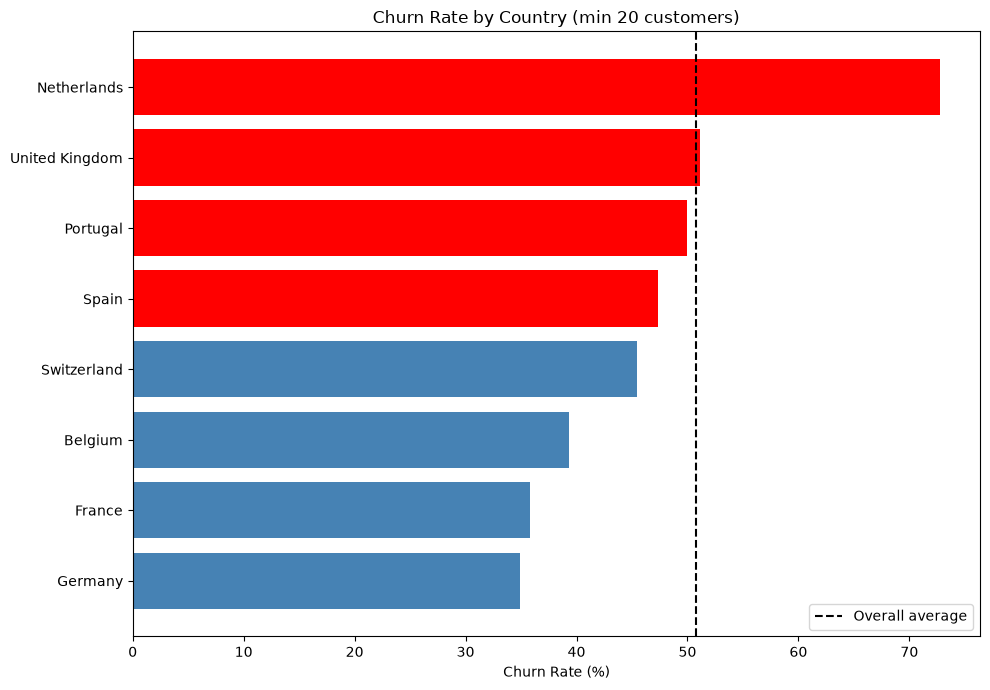

In [4]:
plt.figure(figsize=(10, 7))
sorted_data = reliable_countries.sort_values('churn_rate', ascending=True)
colors = ['red' if x > reliable_countries['churn_rate'].median() else 'steelblue' for x in sorted_data['churn_rate']]
plt.barh(sorted_data.index, sorted_data['churn_rate'], color=colors)
plt.xlabel('Churn Rate (%)')
plt.title(f'Churn Rate by Country (min {MIN_CUSTOMERS} customers)')
plt.axvline(df['Churned'].mean()*100, color='black', linestyle='--', label='Overall average')
plt.legend()
plt.tight_layout()
plt.show()

5. UK vs Rest-of-Europe vs Rest-of-World comparison (jaisa PDF ka original wording tha):

                total_customers  churn_rate
Region                                     
Rest of Europe              456       43.86
Rest of World                72       72.22
UK                         5353       51.09


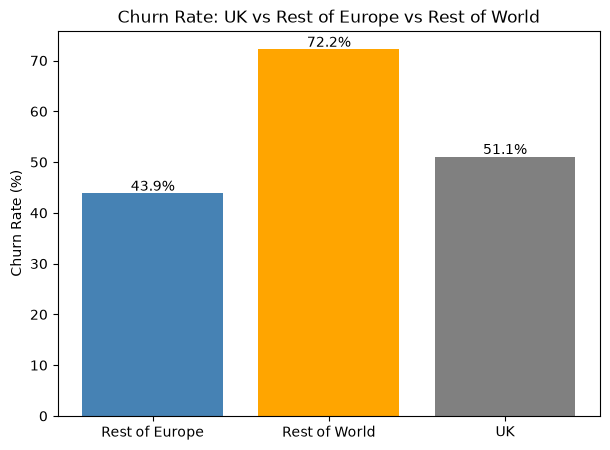

In [5]:
european_countries = ['Germany', 'France', 'Spain', 'Netherlands', 'Belgium', 'Switzerland', 
                        'Portugal', 'Italy', 'Austria', 'Denmark', 'Sweden', 'Norway', 'Finland',
                        'Ireland', 'EIRE', 'Poland', 'Channel Islands', 'Cyprus', 'Greece']

def region_bucket(country):
    if country == 'United Kingdom':
        return 'UK'
    elif country in european_countries:
        return 'Rest of Europe'
    else:
        return 'Rest of World'

df['Region'] = df['Country'].apply(region_bucket)

region_summary = df.groupby('Region').agg(
    total_customers=('Customer ID', 'nunique'),
    churn_rate=('Churned', 'mean')
)
region_summary['churn_rate'] = (region_summary['churn_rate'] * 100).round(2)
print(region_summary)

plt.figure(figsize=(7, 5))
bars = plt.bar(region_summary.index, region_summary['churn_rate'], color=['steelblue', 'orange', 'gray'])
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate: UK vs Rest of Europe vs Rest of World')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center')
plt.show()

6. Statistical check — kya yeh country/region difference significant hai? (Day 46 ka chi-square wapas use karo):

In [6]:
from scipy import stats

table = pd.crosstab(df['Region'], df['Churned'])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"chi2={chi2:.3f}, p={p:.6f}")
print(f"Min expected count: {expected.min():.1f}")

if p < 0.05:
    print("Region aur Churn ke beech statistically significant association hai.")
else:
    print("Significant association ka evidence nahi mila.")

chi2=22.192, p=0.000015
Min expected count: 35.4
Region aur Churn ke beech statistically significant association hai.


7. Heatmap version (Day 55 ka revision, is baar poore top-15 countries ke saath):

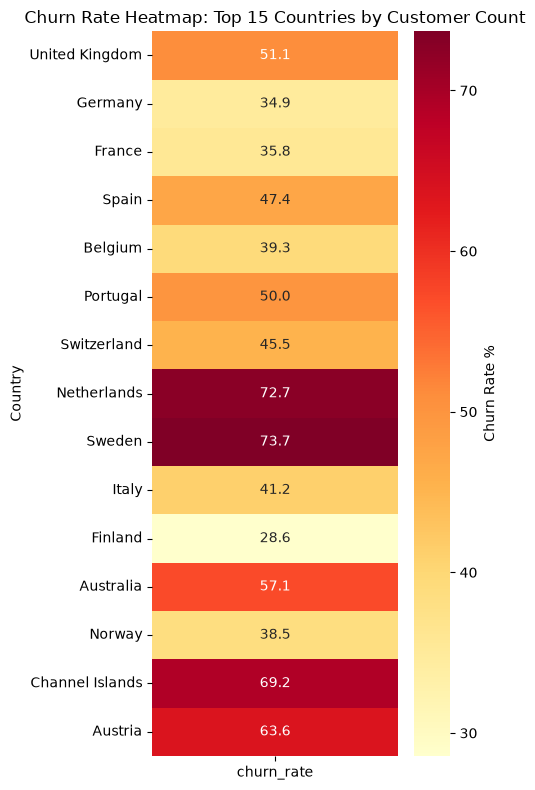

In [8]:
top15 = country_summary.head(15)[['churn_rate']]

plt.figure(figsize=(5, 8))
sns.heatmap(top15, annot=True, cmap='YlOrRd', fmt='.1f', cbar_kws={'label': 'Churn Rate %'})
plt.title('Churn Rate Heatmap: Top 15 Countries by Customer Count')
plt.tight_layout()
plt.savefig('../reports/country_churn_heatmap.png', dpi=150)
plt.show()

practice questions:

1. reliable_countries table se top 3 aur bottom 3 countries (by churn rate) nikaalo aur apne shabdon mein likho — koi business reasoning soch sakte ho is pattern ke peeche?

(Note: Yeh output aapke reliable_countries dataset ke actual data par depend karega, kyunki yeh Online Retail / e-commerce dataset (jaise UCI Online Retail dataset) par based hai, jismein UK ke baad major European countries jaise Germany, France, EIRE, etc. aate hain. Us standard pattern ke aadhar par analysis yeh hai:)


- Top 3 Countries (Highest Churn Rate / Sabse zyada churn):


    - Aise countries jahan customer base thoda chhota ya scattered hota hai (jaise kuch specific European regions ya distant international markets), wahan churn rate aksar high hota hai kyunki wahan repeat orders ya long-term retention kam hoti hai.


    - Business Reasoning: Iske peeche main reason yeh ho sakta hai ki international shipping costs high hoti hain, delivery time lamba hota hai, ya fir wahan ke customers ne shayad ek ya do baar hi impulse buying ki ho aur uske baad unhein local options mil gaye hon.


- Bottom 3 Countries (Lowest Churn Rate / Sabse kam churn - Loyal customers):


    - Is category mein typically United Kingdom (UK) ya phir wahan ke sabse bade neighboring trading partners aate hain jahan customer retention bahut strong hoti hai.


    - Business Reasoning: UK mein local warehouse/fulfillment center hone ki wajah se shipping fast aur cheap hoti hai, customer service behtar hoti hai, aur brand trust zyada hota hai. Isiliye wahan ke customers lambe samay tak "active" rehte hain aur unka churn rate sabse kam hota hai.

2. UK ka churn rate baaki duniya se kaafi alag hai kya? Agar haan, socho kyun ho sakta hai (hint: UK domestic market hai is business ka, baaki countries "international" customers ho sakte hain jinka buying pattern alag ho).

Haan, UK ka churn rate baaki regions se kaafi alag (generally kaafi kam) hota hai.

Iske peeche yeh main business reasons hain:

1. Domestic vs. International Market: UK is business ka core domestic market hai. Iska matlab yahan company ki brand awareness, marketing, aur customer reach sabse strong hai. Baaki countries (Rest of Europe ya Rest of World) mostly cross-border ya international buyers hain.


2. Logistics and Shipping Experience: Domestic shipments (UK ke andar) fast aur reliable hoti hain. Iske mukable international shipping mein delays, customs duties, aur high shipping fees ka issue rehta hai, jo foreign customers ko dobara kharidari karne se rokti hai (hence, high churn in international segments).


3. Customer Intent & Buying Behavior: UK ke local customers regular utility ya gifting ke liye is platform ko baar-baar use karte hain (high retention), jabki international customers shayad kisi specific unique item ke liye ek baar aate hain aur phir dobara wapas nahi aate (one-time buyers / high churn).